# Analyze imgep dataset
## Explain what are bus and ddr bandwidths
* DDR bandwidth: For a given time cycle window, number of instructions that are transmitted from the DDR controller to the DDR main memory. Method sim070726.Var.log_ddr_command implements this metric
* BUS bandwidth: For a given time cycle window, number of instructions that are transmitted from the Interconnect to the DDR controller.
Remark: One can track bandwidth for type of instruction, that is write or read

## Load exploration results

In [1]:
import pickle
import numpy  as np
from exploration.load_file import load
from diversity.diversty import Diversity
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN

In [2]:
#Load data
folder = "results"
N = 100000
k=1
print_freq = 1000
name_imgep = f'{folder}/imgep_bandwidth_N_{N}_k_{k}'
name_random = f'{folder}/random_bandwidth_expl_N_{N}'
content_imgep = load(name_imgep)
content_imgep_tab = content_imgep['numpy_view']
content_random = load(name_random)
content_random_tab = content_random['numpy_view']
dim_out = 30




results/imgep_bandwidth_N_100000_k_1_2.pkl
results/random_bandwidth_expl_N_100000_3.pkl


In [4]:
#Compute diversity
##################################
min_tab = np.zeros((dim_out,))
max_tab = np.ones((dim_out,))*10
diversity_imgep_list = [100* Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = num_bins)(content_imgep_tab[:])/(num_bins**dim_out) for num_bins in range(2,10)]
diversity_random_list = [100*Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = num_bins)(content_random_tab[:])/(num_bins**dim_out) for num_bins in range(2,10)]

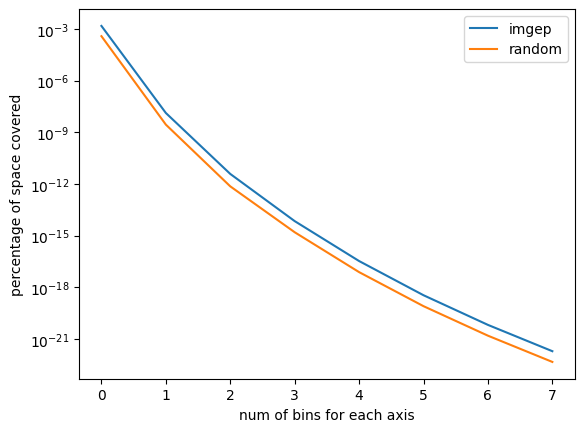

In [6]:
plt.semilogy(diversity_imgep_list,label='imgep')
plt.semilogy(diversity_random_list,label='random')
plt.ylabel('percentage of space covered')
plt.xlabel('num of bins for each axis')
plt.legend()

In [7]:
step = 1000
diversity_imgep_list = [100* Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = 10)(content_imgep_tab[:step]) for step in range(step,N+1,step)]
diversity_random_list = [100*Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = 10)(content_random_tab[:step]) for step in range(step,N+1,step)]

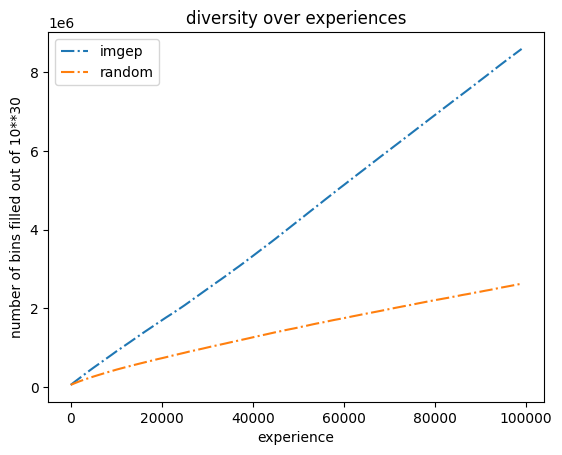

In [8]:
#print(f'diversity imgep {diversity_(content_imgep_tab)}/10**{dim_out}')
#print(f'diversity random {diversity_(content_random_tab)}/10**{dim_out}')
plt.figure()
plt.plot(range(0,N,print_freq),diversity_imgep_list,'-.',label="imgep")
plt.plot(range(0,N,print_freq),diversity_random_list,'-.',label="random")
plt.legend()
plt.title('diversity over experiences')
plt.xlabel('experience')
plt.ylabel(f'number of bins filled out of 10**{dim_out}')
plt.show()

In [9]:
content_imgep['memory_observation'].keys()

dict_keys(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff', 'bus_bandwidth_core_0_read_diff', 'ddr_bandwidth_core_0_read_diff', 'bus_bandwidth_core_0_write_diff', 'ddr_bandwidth_core_0_write_diff', 'bus_bandwidth_core_0_iso', 'bus_bandwidth_core_0_core1', 'ddr_bandwidth_core_0_iso', 'ddr_bandwidth_core_0_core1', 'time_core0_iso', 'time_core0_core1'])

### Imgep finds more various points than random. One would like to identify potential clusters in the dataset. For each time window, we focus on a 3D dimensional space, as we select variables that are different between isolation and parallel execution.
### Although no cluster is naturally appearing, one will employ (SVD,HDBSAN), (UMAP,HDBSCAN) and Kmeans to support this claim.

# One will color the following plots with the obtain clusters for constructive comparison between the methods

In [3]:
combinaisons = lambda dimension: [(i,j) for j in range(1,dimension) for i in range(j)] 

In [4]:
content_imgep['memory_observation'].keys()

dict_keys(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff', 'bus_bandwidth_core_0_read_diff', 'ddr_bandwidth_core_0_read_diff', 'bus_bandwidth_core_0_write_diff', 'ddr_bandwidth_core_0_write_diff', 'bus_bandwidth_core_0_iso', 'bus_bandwidth_core_0_core1', 'ddr_bandwidth_core_0_iso', 'ddr_bandwidth_core_0_core1', 'time_core0_iso', 'time_core0_core1'])

In [13]:
list_feature = ['bus_bandwidth_core_0_read_diff', 'ddr_bandwidth_core_0_read_diff', 'bus_bandwidth_core_0_write_diff', 'ddr_bandwidth_core_0_write_diff', 'cache_misses_l2_diff']

In [21]:
list_feature = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff']
def plot_features(list_feature,figsize = (24,12)):
    combins = combinaisons(len(list_feature))
    fig,axs = plt.subplots(len(combins),6,figsize=figsize)
    for paire,(i,j) in enumerate(combins):
        for time in range(0,6):
            axs[paire,time].scatter(np.array(content_imgep['memory_observation'][list_feature[i]])[:,time],np.array(content_imgep['memory_observation'][list_feature[j]])[:,time],label='imgep')
            axs[paire,time].scatter(np.array(content_random['memory_observation'][list_feature[i]])[:,time],np.array(content_random['memory_observation'][list_feature[j]])[:,time],label='random')
            axs[paire,time].set_xlabel(list_feature[i])
            if paire==0:
                axs[0,time].set_title(f'time window {time}')
        axs[paire,0].set_ylabel(list_feature[j])
    axs[0,0].legend()

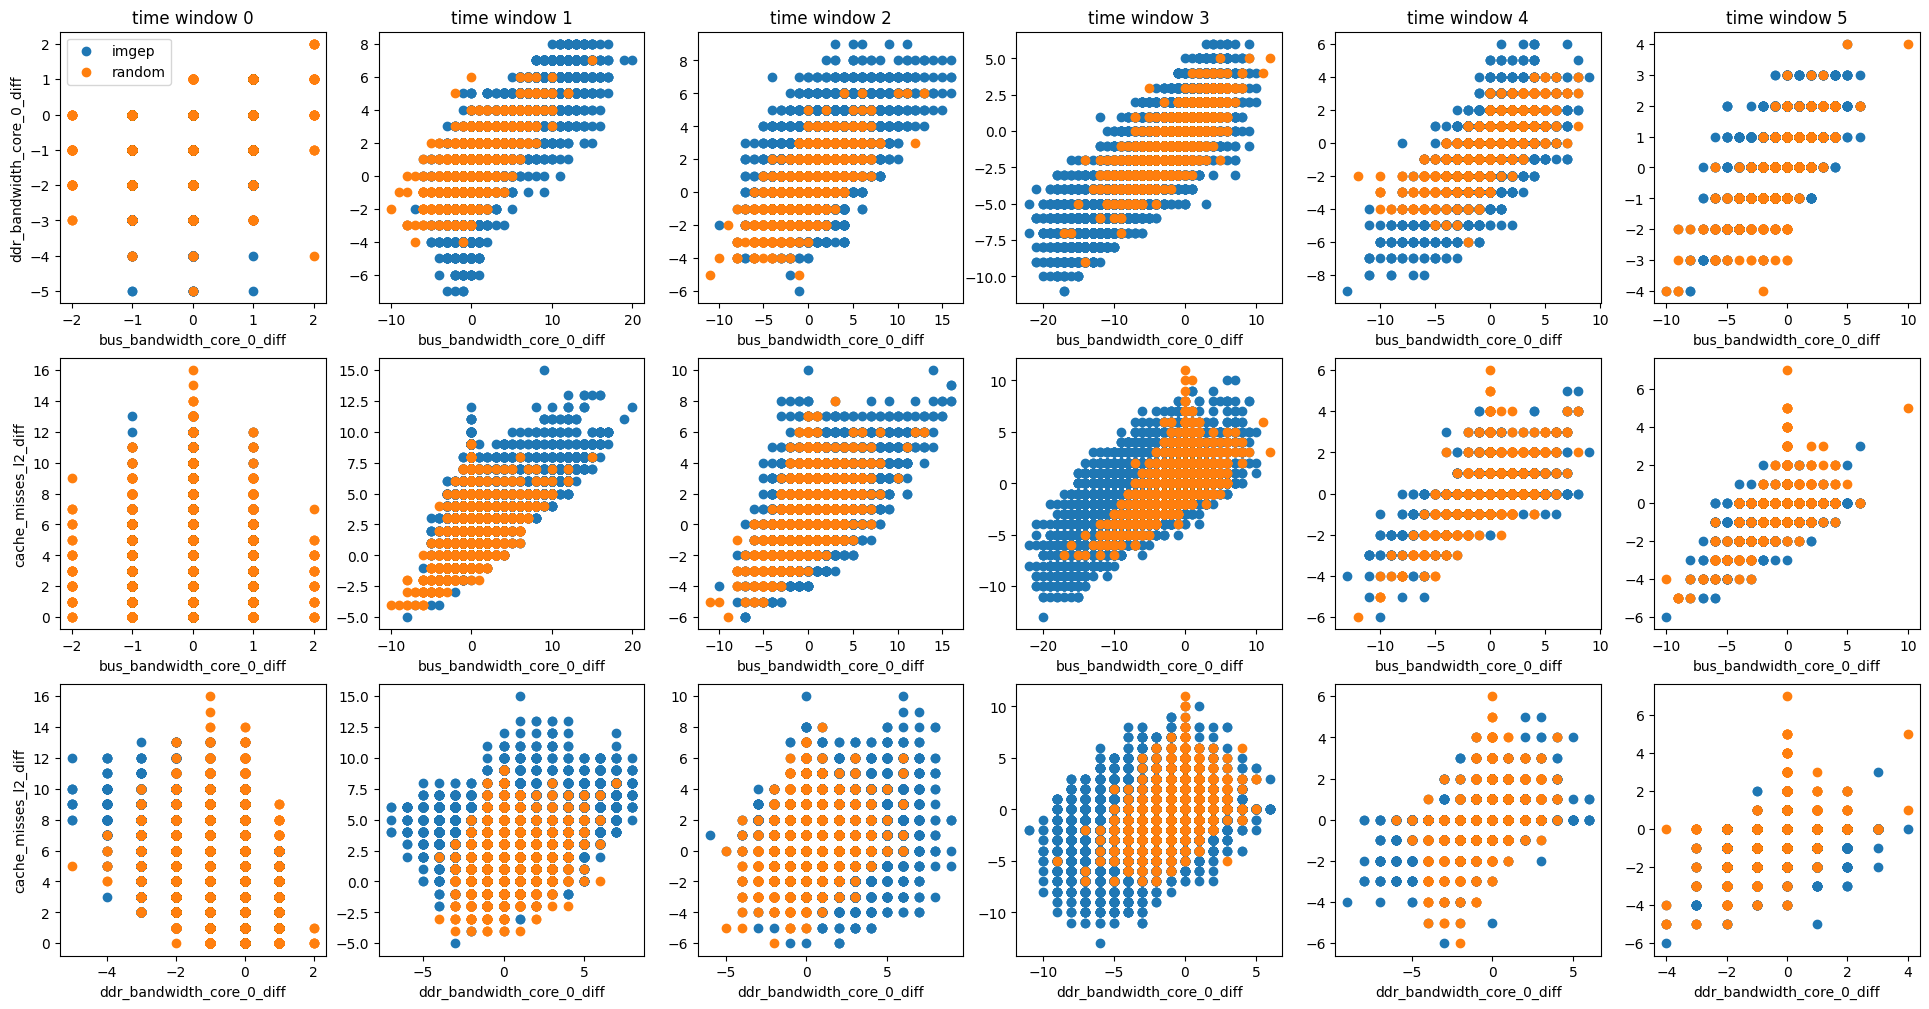

In [22]:
plot_features(list_feature)

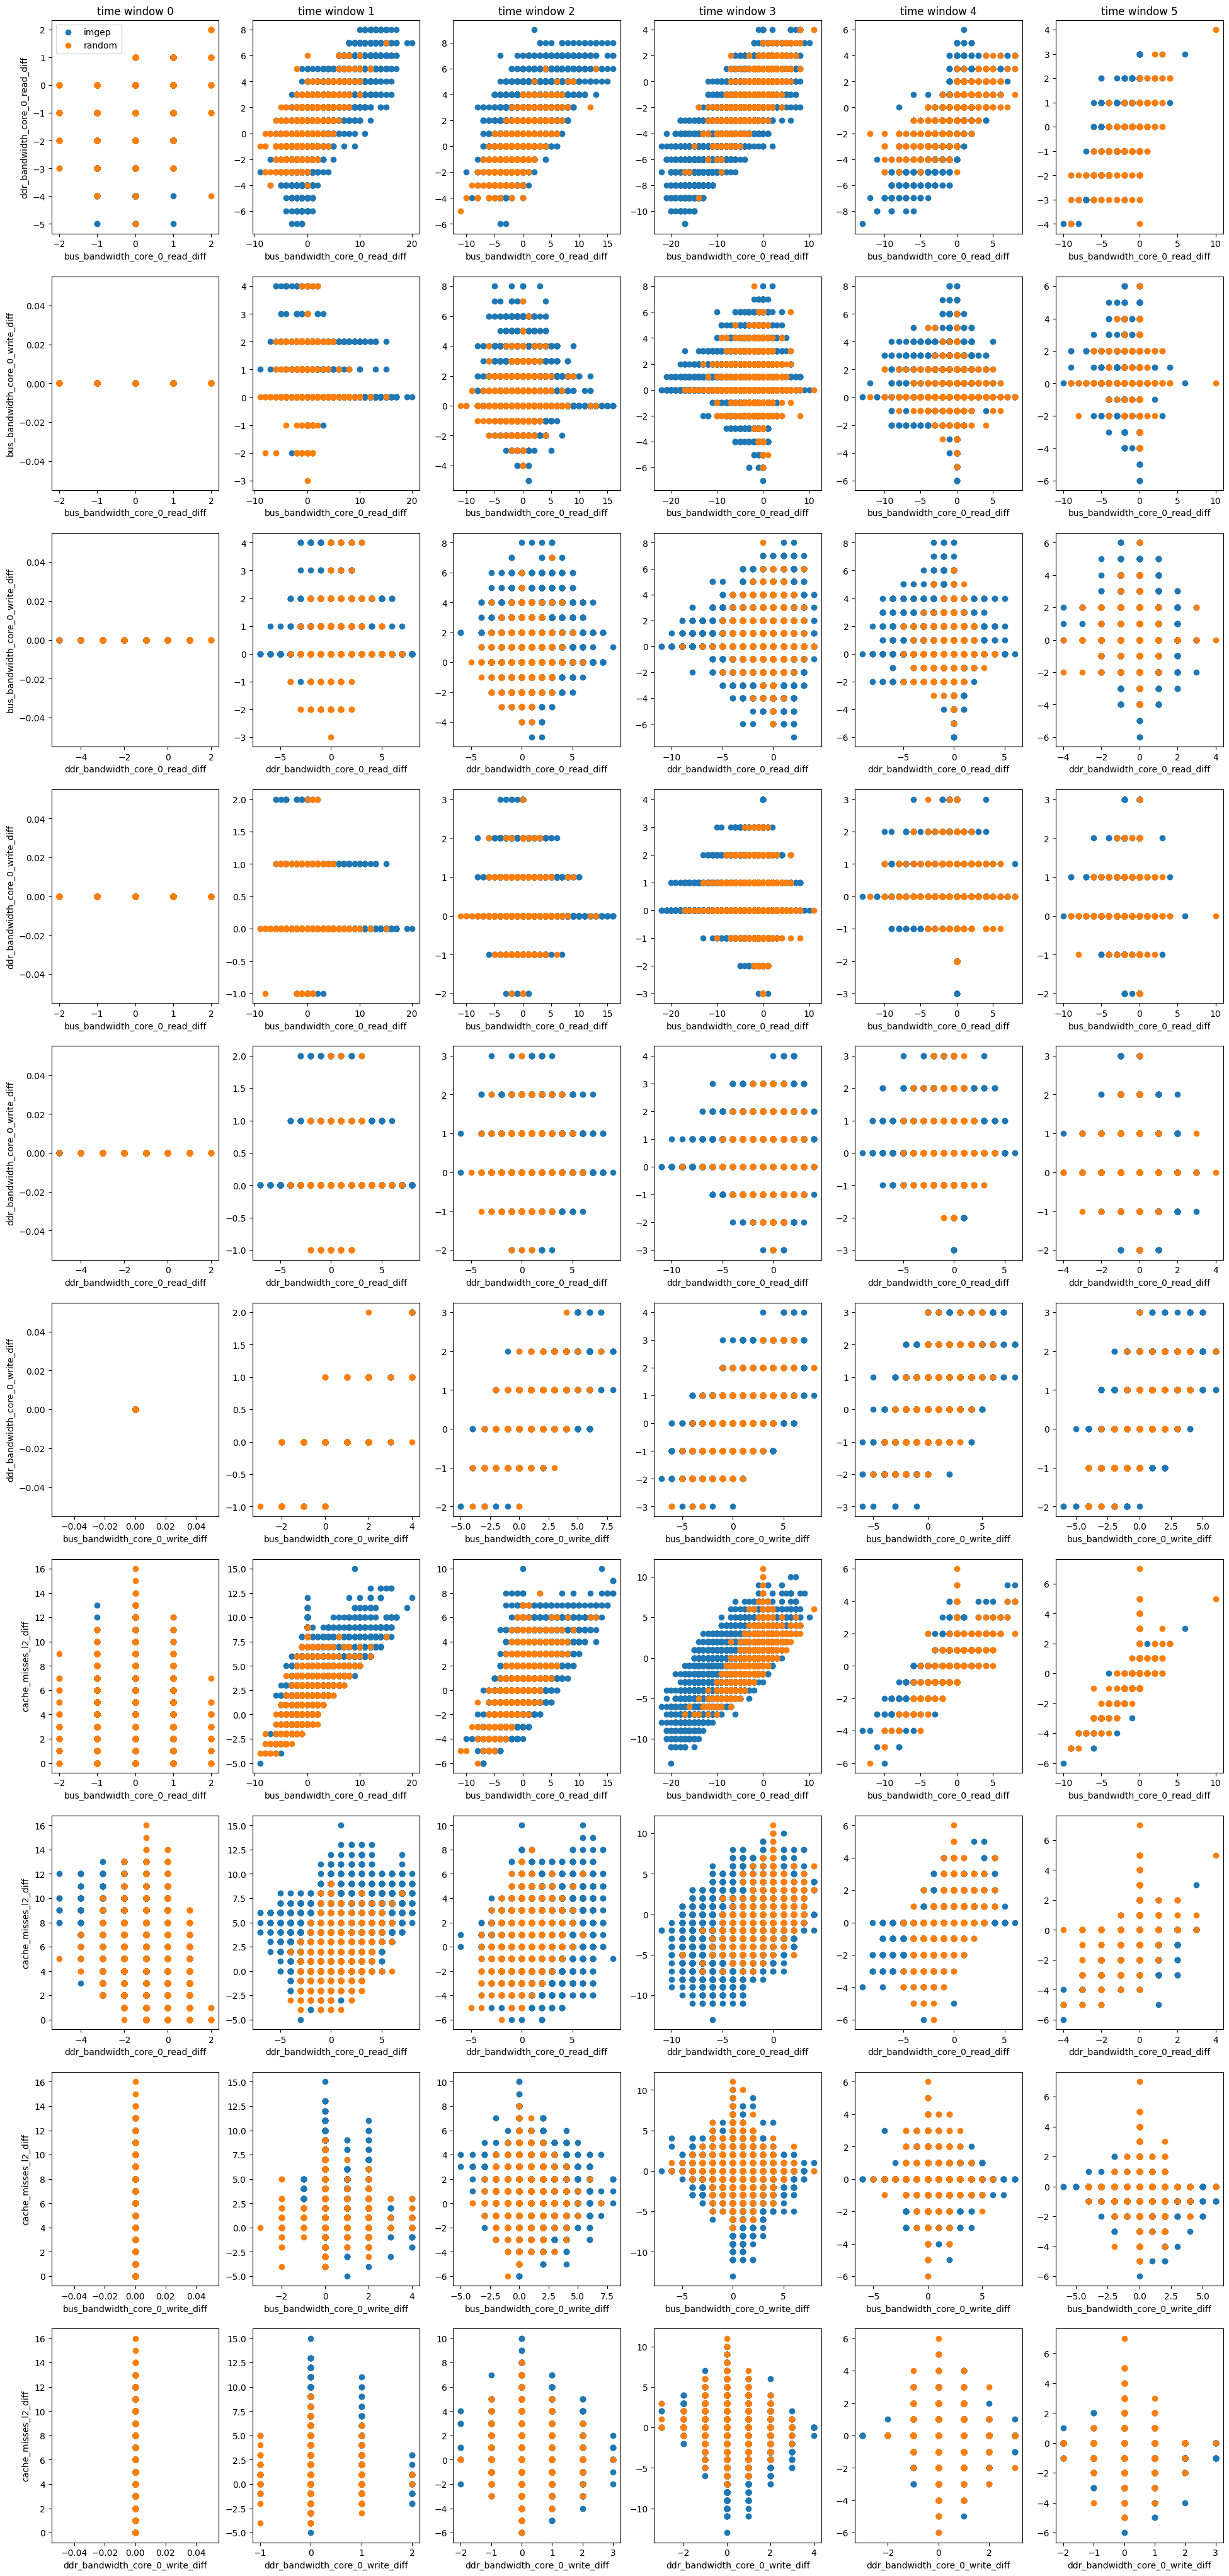

In [23]:
plot_features(['bus_bandwidth_core_0_read_diff', 'ddr_bandwidth_core_0_read_diff', 'bus_bandwidth_core_0_write_diff', 'ddr_bandwidth_core_0_write_diff', 'cache_misses_l2_diff'],figsize=(24,52))

In [13]:
list_feature = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff']
def plot_features_with_time(list_feature,figsize = (36,12)):
    fig,axs = plt.subplots(1,len(list_feature),figsize=figsize)
    y = np.array(content_imgep['memory_observation']['time_core0_core1']) - np.array(content_imgep['memory_observation']['time_core0_iso'])
    for i,feature in enumerate(list_feature):
            axs[i].scatter(np.mean(np.array(content_imgep['memory_observation'][feature])[:,:],axis=1),y,label='imgep')
            axs[i].scatter(np.mean(np.array(content_random['memory_observation'][feature])[:,:],axis=1),y,label='random')
            axs[i].set_xlabel(list_feature[i])
            axs[i].set_ylabel('time [non-iso] - time[iso] core 0')
    axs[0].legend()

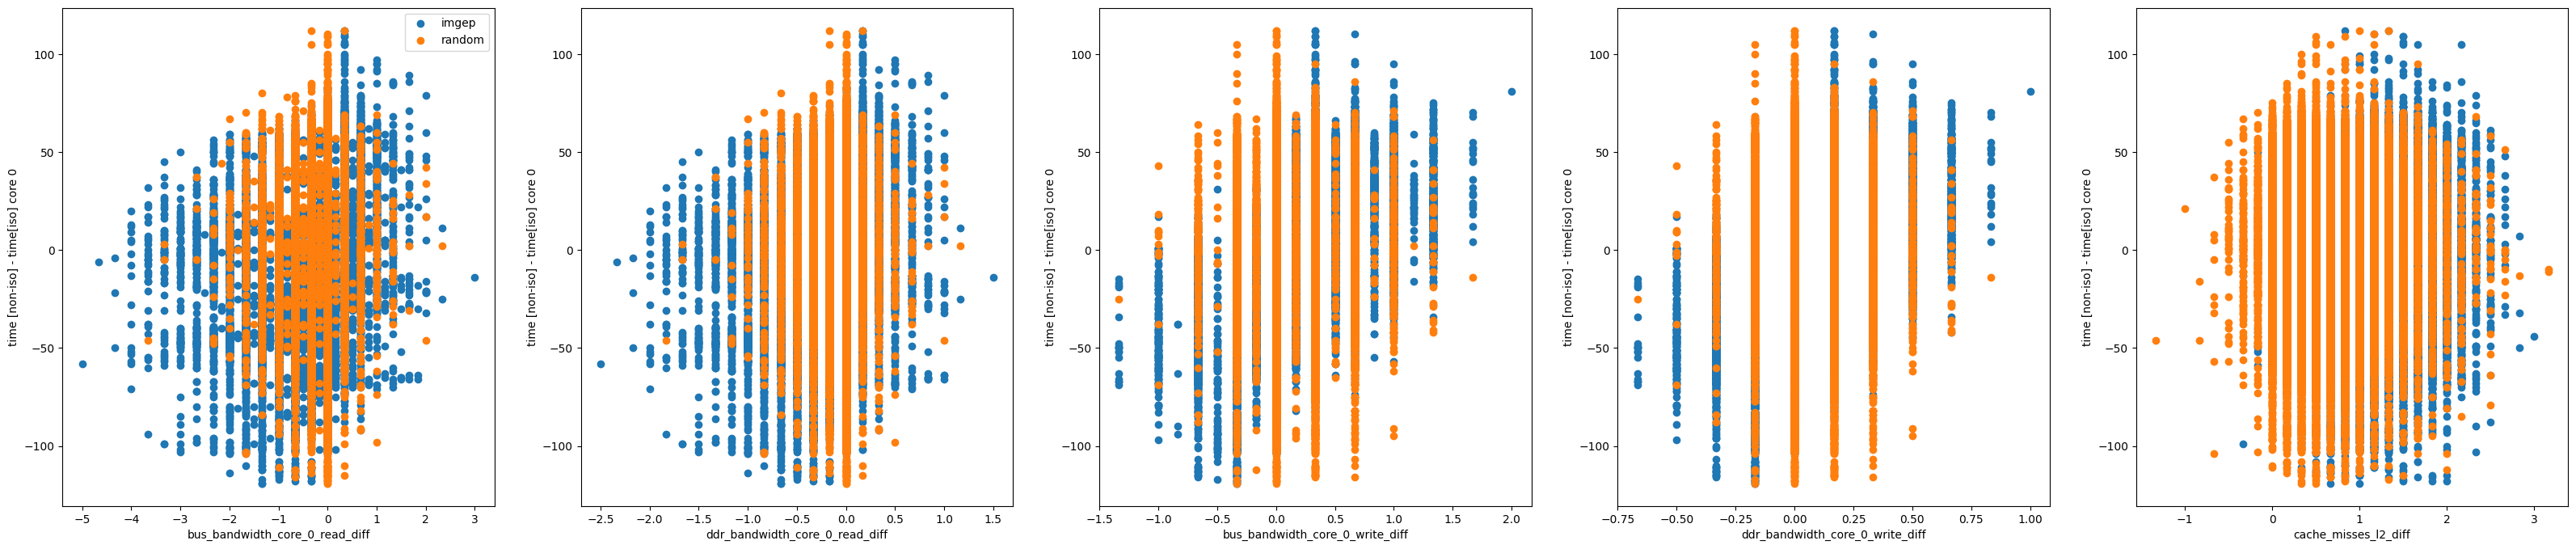

In [16]:
plot_features_with_time(['bus_bandwidth_core_0_read_diff', 'ddr_bandwidth_core_0_read_diff', 'bus_bandwidth_core_0_write_diff', 'ddr_bandwidth_core_0_write_diff', 'cache_misses_l2_diff'],(40,8))

# Attempt to identify clusters with SVD

### Assuming there is a latent representation of each time stamp, for each time window t, we consider a population where individuals are outputs of experiments. As a result, eigein values are all non-neglectable and no cluster appears on the projected data plots, as no seperation is visible.

In [27]:
feature_list = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff']

In [28]:
content_imgep['memory_observation']
content_array_time  = np.array([[[content_imgep['memory_observation'][feature][n][t] for feature in feature_list] for t in range(6)] for n in range(N)])

In [29]:
norm_mean_std = lambda data: (data - data.mean(axis=0))/data.std(axis=0)

sigma diagonal for t=0 [377.76298133 315.89698621 239.80038373]
sigma diagonal for t=1 [455.6642981  279.91114078 118.40523935]
sigma diagonal for t=2 [417.58448495 306.59778296 177.82293839]
sigma diagonal for t=3 [484.8452612  239.74891708  86.28748142]
sigma diagonal for t=4 [426.57993213 286.2575228  189.96366007]
sigma diagonal for t=5 [458.34338162 261.71588391 146.37670797]


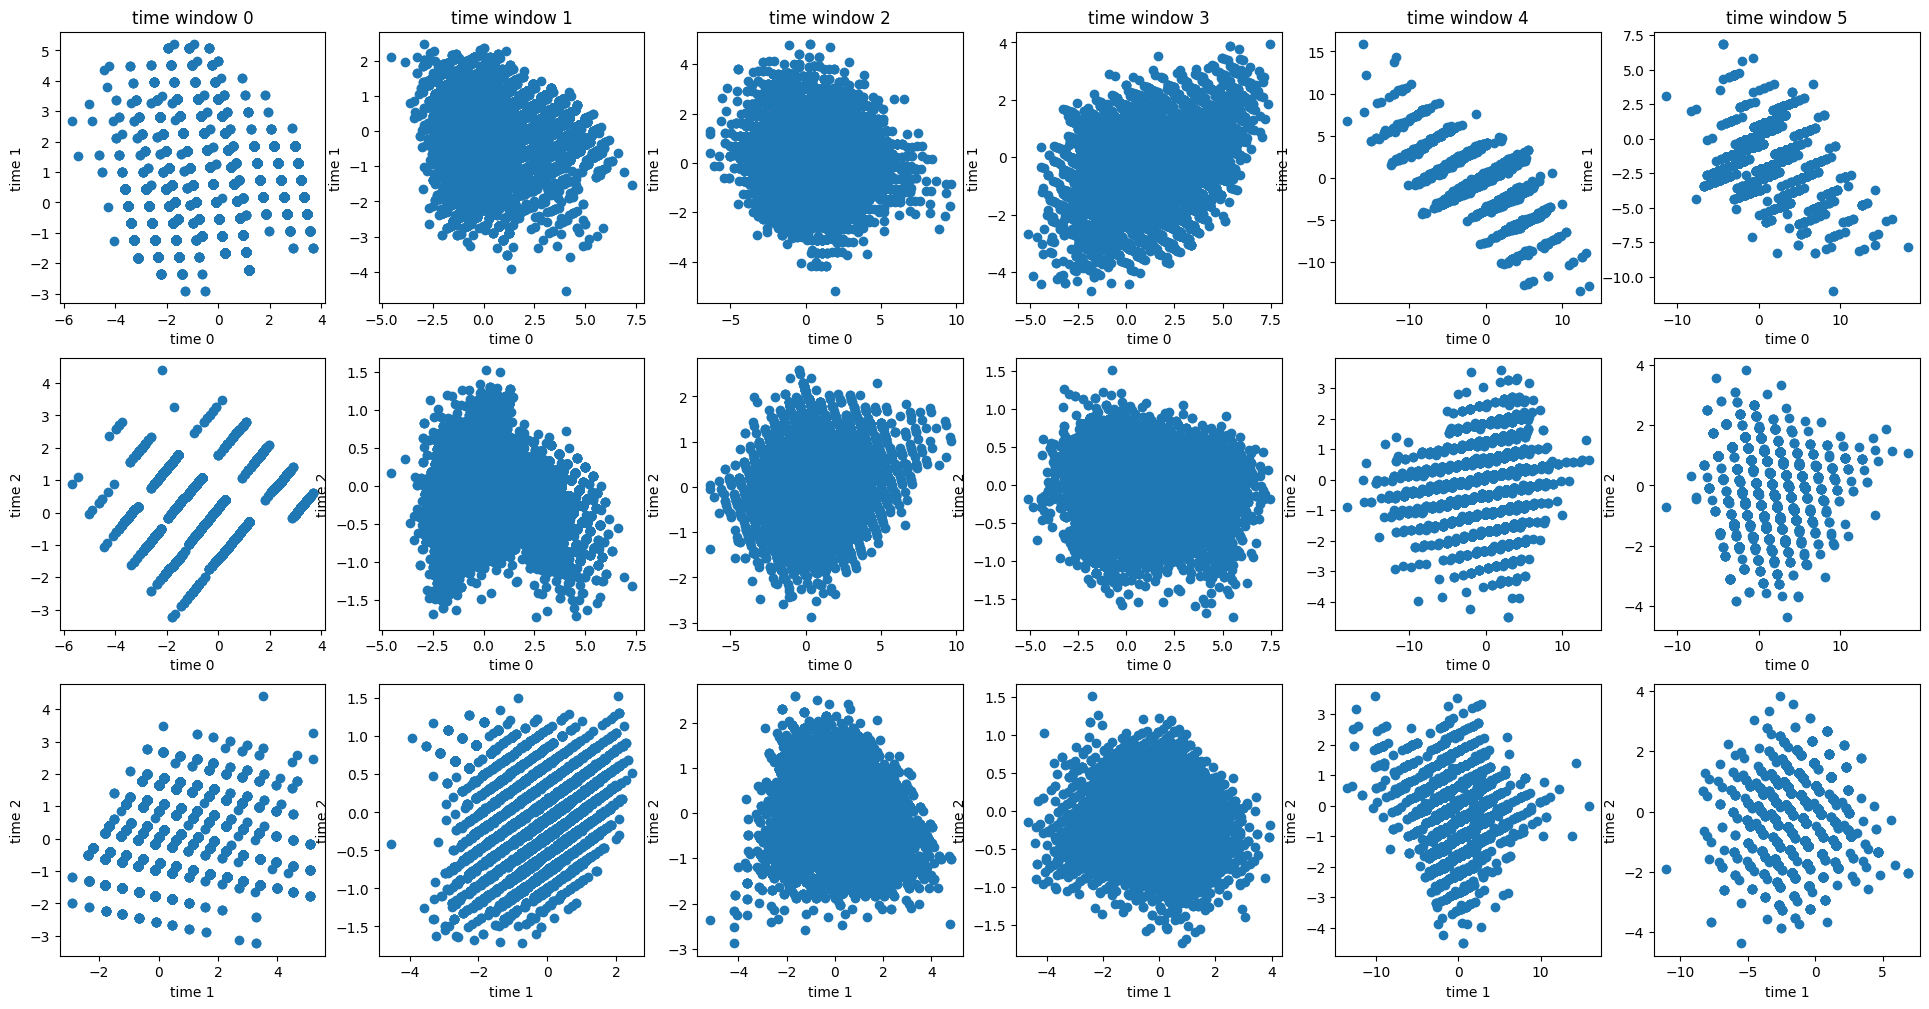

In [30]:
coords = combinaisons(3)
fig,axs = plt.subplots(len(coords),6,figsize=(24,12))
for t in range(6):
    X = content_array_time[:,t,:]
    X = norm_mean_std(X)
    U,Sig,Vt = np.linalg.svd(X,full_matrices=False)
    proj = U*Sig
    print(f'sigma diagonal for t={t}',Sig)
    proj[0]
    for c,(i,j) in enumerate(coords[:]):
        axs[c,t].scatter(proj[:,i],proj[:,j])    
        axs[c,t].set_xlabel(f'time {i}')
        axs[c,t].set_ylabel(f'time {j}')
    axs[0,t].set_title(f'time window {t}')
    #axs[t,c].legend()
#fig.tight_layout()
plt.show()

### Let's try HDBSCAN on the last time window projection

In [76]:
hdb = HDBSCAN(copy=True, min_cluster_size=1000)
hdb.fit(proj[:,:])

,min_cluster_size,1000
,min_samples,None
,cluster_selection_epsilon,0.0
,max_cluster_size,None
,metric,'euclidean'
,metric_params,None
,alpha,1.0
,algorithm,'auto'
,leaf_size,40
,n_jobs,None
,cluster_selection_method,'eom'


In [77]:
data_list = {key:[] for key in np.unique(hdb.labels_)}   
for j in range(N):
    data_list[hdb.labels_[j]].append(proj[j])
for label in data_list:
    print(f'num elem label {label}: {len(data_list[label])}')
    data_list[label] = np.array(data_list[label])

num elem label -1: 1610
num elem label 0: 1024
num elem label 1: 1251
num elem label 2: 2204
num elem label 3: 2161
num elem label 4: 1313
num elem label 5: 12415
num elem label 6: 75898
num elem label 7: 2124


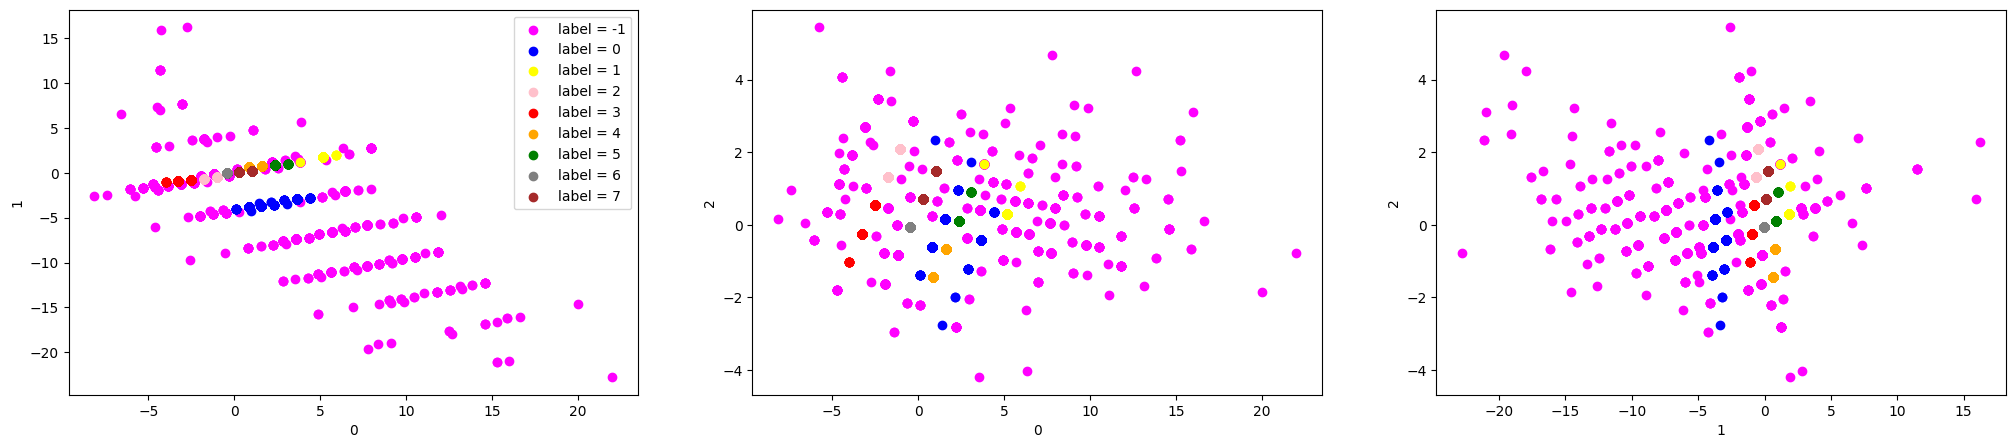

In [78]:
coords = combinaisons(3)
fig,axs = plt.subplots(1,len(coords),figsize=(25,5))
for clust in np.unique(hdb.labels_):
        for c,(i,j) in enumerate(coords):
            axs[c].scatter(data_list[clust][:,i],data_list[clust][:,j],color = ['blue','yellow','pink','red','orange','green','gray','brown','purple','magenta'][clust],label=f'label = {clust}')   
            axs[c].set_xlabel(i)
            axs[c].set_ylabel(j)
axs[0].legend()

## One does not identify cluster with an SVD on the matrix containing all data, each individual is contenation of flatten trajectories of features. Moreover, one can barely reduce the total dimension, suggesting that there is no lower dimension latent phenomena behind our time series

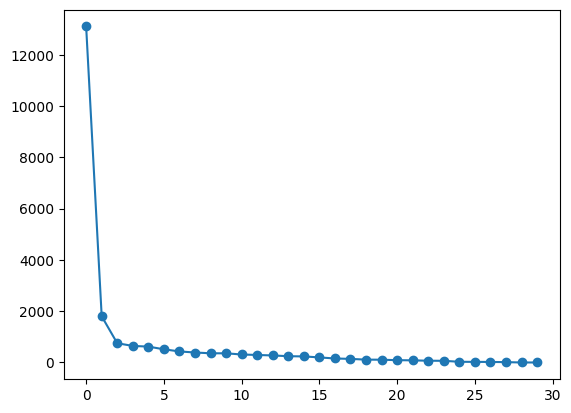

Sigma [1.31018736e+04 1.80157842e+03 7.50506003e+02 6.46024351e+02
 6.18975373e+02 5.14424096e+02 4.30649206e+02 3.88760272e+02
 3.58546744e+02 3.57436534e+02 3.11232828e+02 2.93008151e+02
 2.74191722e+02 2.44759548e+02 2.36342388e+02 1.97589751e+02
 1.55984809e+02 1.40182383e+02 1.10816945e+02 1.08022476e+02
 8.99749643e+01 8.34452413e+01 6.81569527e+01 6.54188742e+01
 2.72710805e+01 2.32112130e+01 2.09126947e+01 1.32642350e+01
 1.18588297e-12 1.18588297e-12]


In [19]:
data = content_imgep['numpy_view']
max_min = data.max(axis=0) - data.min(axis=0)
norm_min_max = lambda data: (data - data.min(axis=0))/(1*max_min==0 + max_min)
data = norm_min_max(data)
U,Sigma,Vt = np.linalg.svd(data,full_matrices = False)
plt.figure()
plt.plot(Sigma,'-o',label='Sigma')
plt.show()
print('Sigma',Sigma)

# UMAP on matrix containing all data, each individual is contenation of flatten trajectories of features

In [5]:
import umap

In [6]:
data = content_imgep['numpy_view']
print('data shape', data.shape)
max_min = data.max(axis=0) - data.min(axis=0)
norm_min_max = lambda data: (data - data.min(axis=0))/(1*max_min==0 + max_min)
data = norm_min_max(data)

data shape (100000, 30)


In [7]:
reducer = umap.UMAP(n_components=5,metric="euclidean")
embedding = reducer.fit_transform(data)

/home/ludovic/directory_env/envir/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [8]:
print(embedding.shape)

(100000, 5)


In [9]:
dimension = 5
idx = [(i,j) for j in range(1,dimension) for i in range(j)]
print(idx)

[(0, 1), (0, 2), (1, 2), (0, 3), (1, 3), (2, 3), (0, 4), (1, 4), (2, 4), (3, 4)]


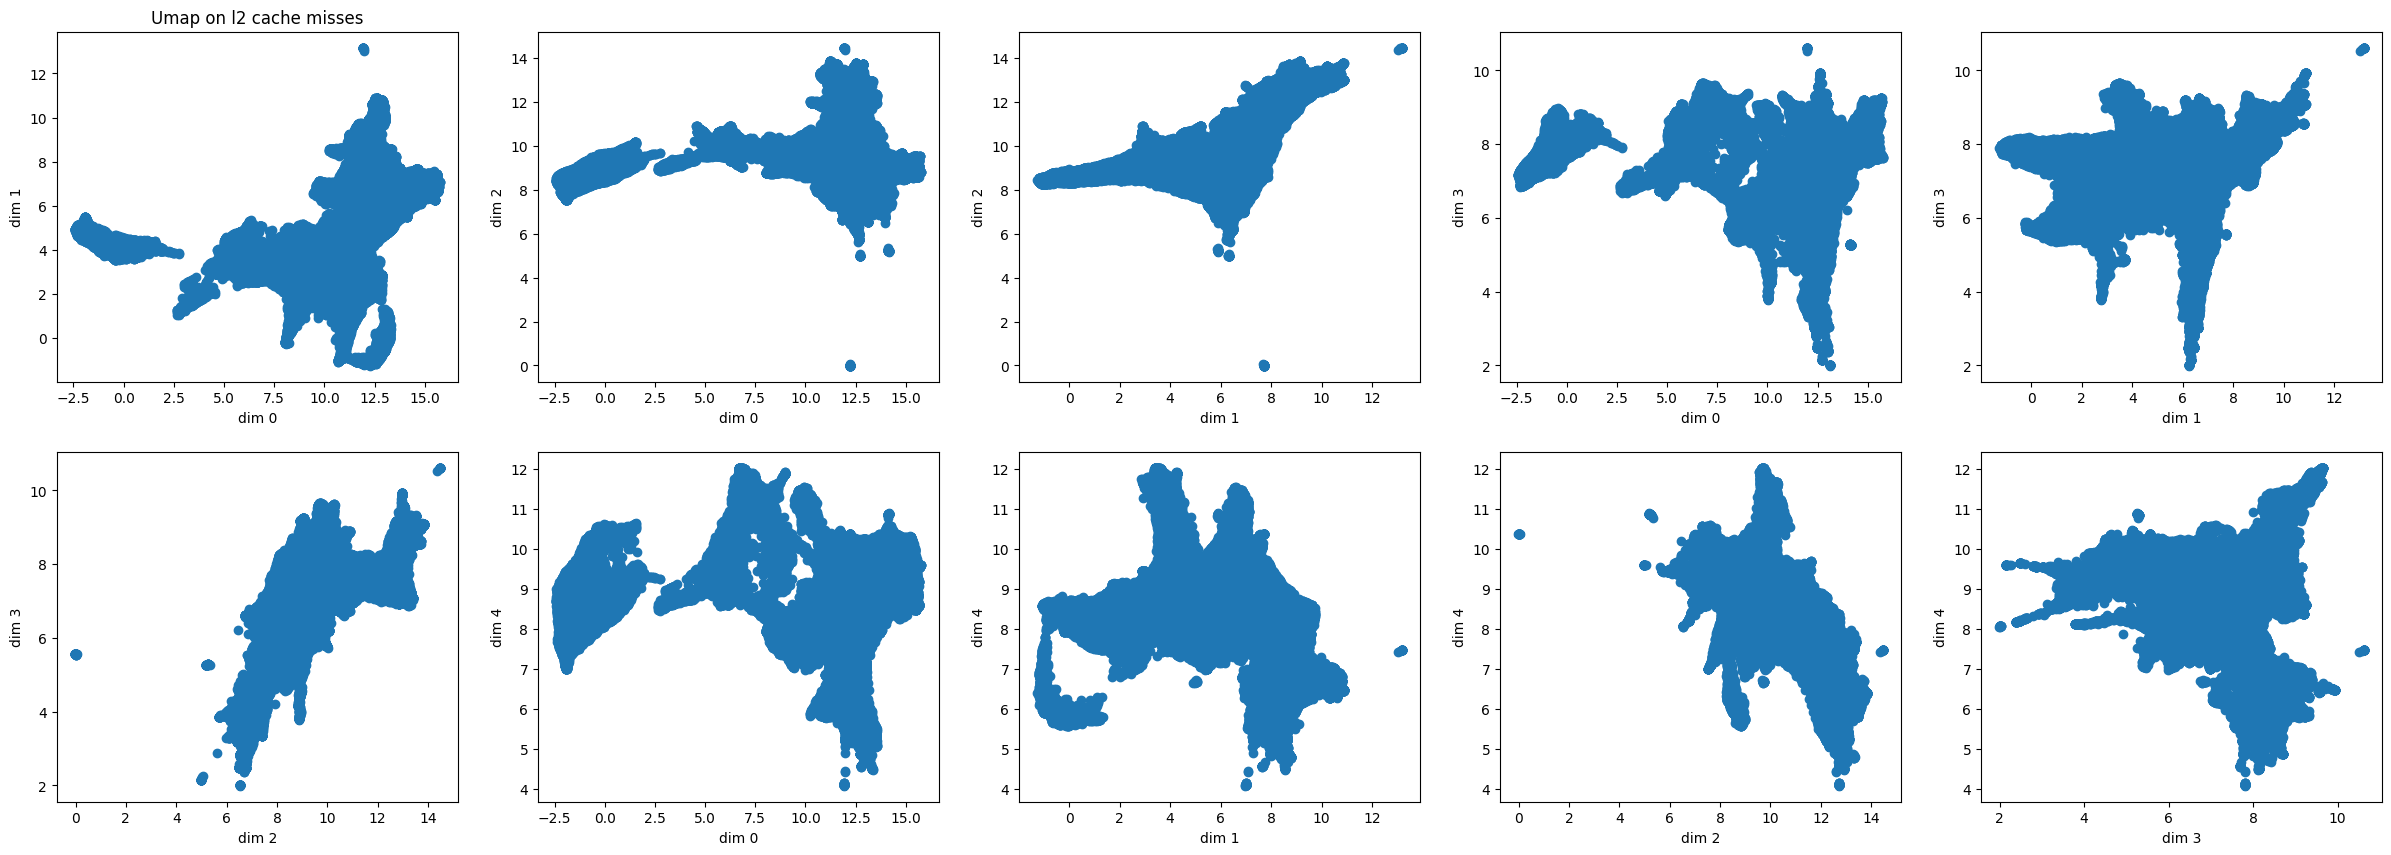

In [10]:
fig,axs=plt.subplots(2,5,figsize=(30,10))
for j in range(len(idx)):
    axs[j//5,j%5].scatter(embedding[:,idx[j][0]],embedding[:,idx[j][1]])
    axs[j//5,j%5].set_xlabel(f'dim {idx[j][0]}')
    axs[j//5,j%5].set_ylabel(f'dim {idx[j][1]}')
    if j==0:
        axs[j//5,j%5].set_title('Umap on l2 cache misses')
plt.show()

# Let's see what see what minimal size for the cluster is obtimal using HDBSCAN.

In [14]:
cluster_sizes = list(range(1000,5001,1000))
products = []
hdb_models = []
for cluster_size in cluster_sizes:
    print(f'cluster size:{cluster_size}')
    hdb = HDBSCAN(copy=True, min_cluster_size=cluster_size)
    hdb.fit(embedding)
    hdb_models.append(hdb)
    product = np.sum(hdb.labels_==-1)*(len(np.unique(hdb.labels_))-1)
    print(f'product {product}')
    products.append(product)

cluster size:1000
ratio 894
cluster size:2000
ratio 7844
cluster size:3000
ratio 10580
cluster size:4000
ratio 20076
cluster size:5000
ratio 27724


In [16]:
noise = [np.sum(hdb.labels_==-1) for hdb in hdb_models]
nb_labels = [len(np.unique(hdb.labels_))-1 for hdb in hdb_models]

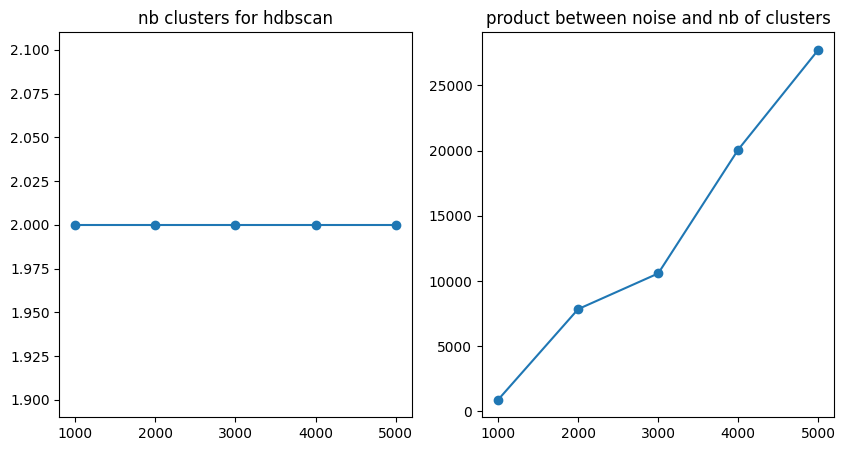

In [35]:
figure,axes = plt.subplots(1,2,figsize=(10,5))
axes[0].plot(cluster_sizes,nb_labels,'-o')
axes[0].set_title('nb clusters for hdbscan')
axes[1].plot(cluster_sizes,products, '-o')
axes[1].set_title('product between noise and nb of clusters')
plt.show()

### We choose the first model as the product between noise and number of clusters is minimal. However, there is more noise elements than the number of elements in the cluster 1

In [32]:
data_list = {key:[] for key in np.unique(hdb_models[0].labels_)}   
for j in range(N):
        data_list[hdb.labels_[j]].append(embedding[j])

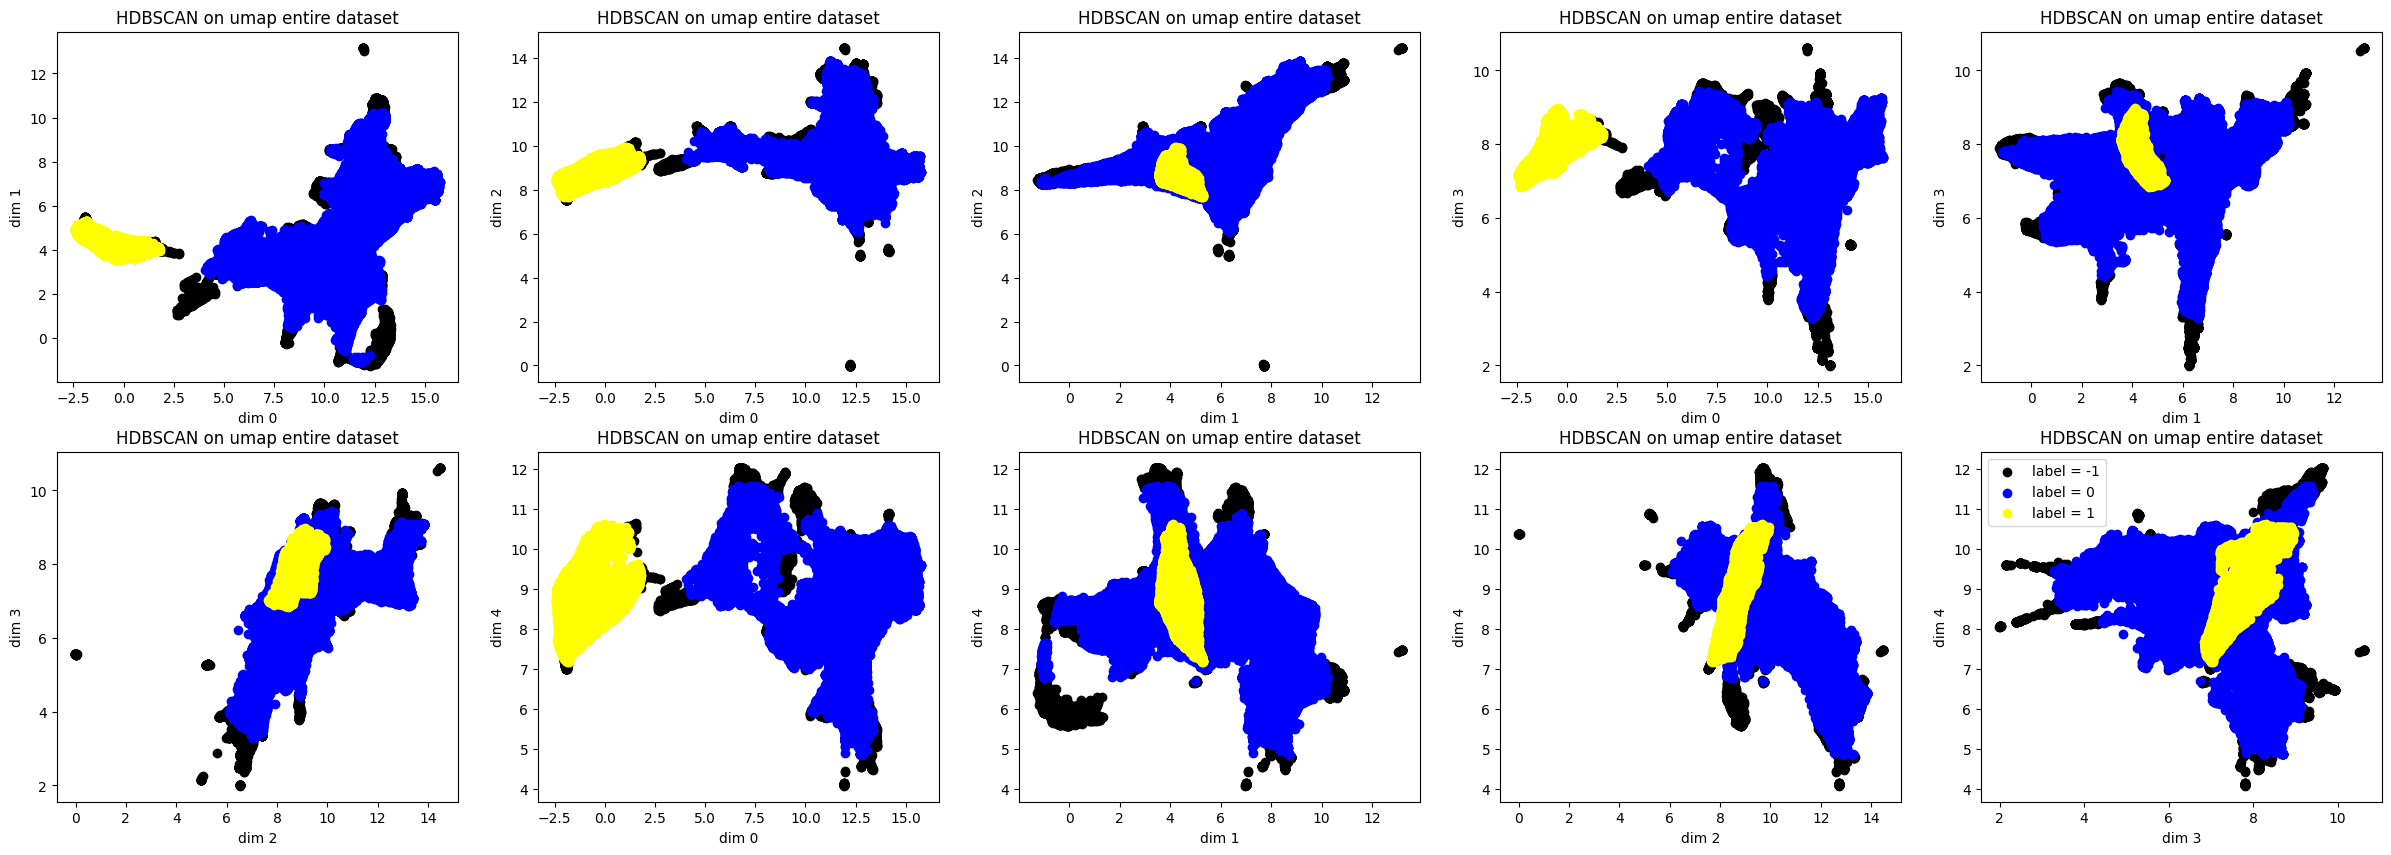

num elem label -1: 13862
num elem label 0: 74237
num elem label 1: 11901


In [33]:
colors = ['black','blue','yellow','pink','red','orange','green','gray','brown','purple','magenta','chartreuse','yellowgreen','tan']
fig,axs=plt.subplots(2,5,figsize=(30,10))
for i in range(len(idx)):
    for j,key in enumerate(data_list):
        axs[i//5,i%5].scatter(np.array(data_list[key])[:,idx[i][0]],np.array(data_list[key])[:,idx[i][1]],color = colors[j],label=f'label = {key}')
        axs[i//5,i%5].set_title('HDBSCAN on umap entire dataset')
        axs[i//5,i%5].set_xlabel(f'dim {idx[i][0]}')
        axs[i//5,i%5].set_ylabel(f'dim {idx[i][1]}')
plt.legend()
plt.show()
for label in data_list:
    print(f'num elem label {label}: {len(data_list[label])}')

In [20]:
clusters_imgep = {key:{feature:[] for feature in content_imgep['memory_observation'].keys()} for key in np.unique(hdb.labels_)}   
for j in range(N):
        for feature in content_imgep['memory_observation']:
            clusters_imgep[hdb.labels_[j]][feature].append(content_imgep['memory_observation'][feature][j])
clusters_imgep = {key:{feature:np.array(clusters_imgep[key][feature]) for feature in clusters_imgep[key]} for key in clusters_imgep}

In [38]:
def plot_clusters(list_feature,clusters_imgep,figsize=(24,12)):
    combins = combinaisons(len(list_feature))
    fig,axs = plt.subplots(len(combins),6,figsize=figsize)
    colors = ['blue','yellow','pink','red','orange','green','gray','brown','purple','magenta','black']
    for paire,(i,j) in enumerate(combins):
        for time in range(0,6):
            for clust in clusters_imgep:
                axs[paire,time].scatter(np.array(clusters_imgep[clust][list_feature[i]])[:,time],np.array(clusters_imgep[clust][list_feature[j]])[:,time],color = colors[clust],label=clust)
                axs[paire,time].set_xlabel(list_feature[i])
                if paire==0:
                    axs[0,time].set_title(f'time window {time}')
        axs[paire,0].set_ylabel(list_feature[j])
    axs[0,0].legend()

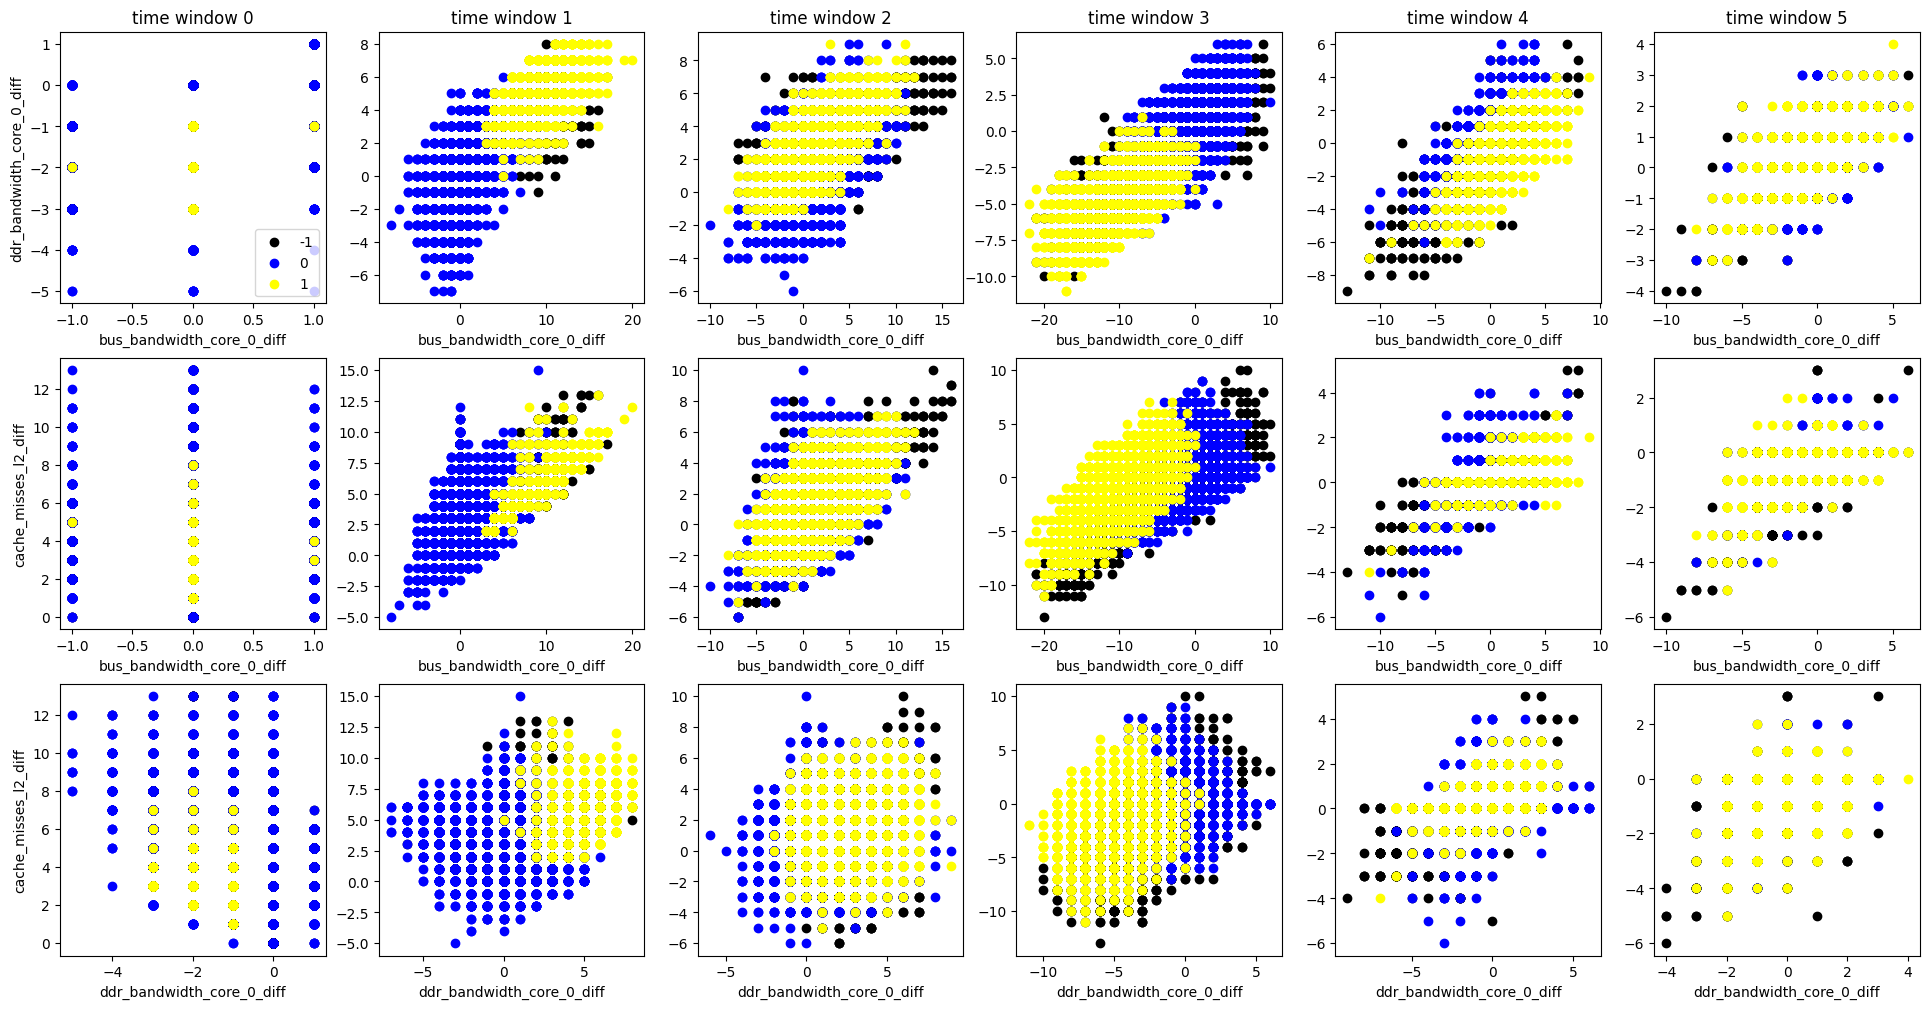

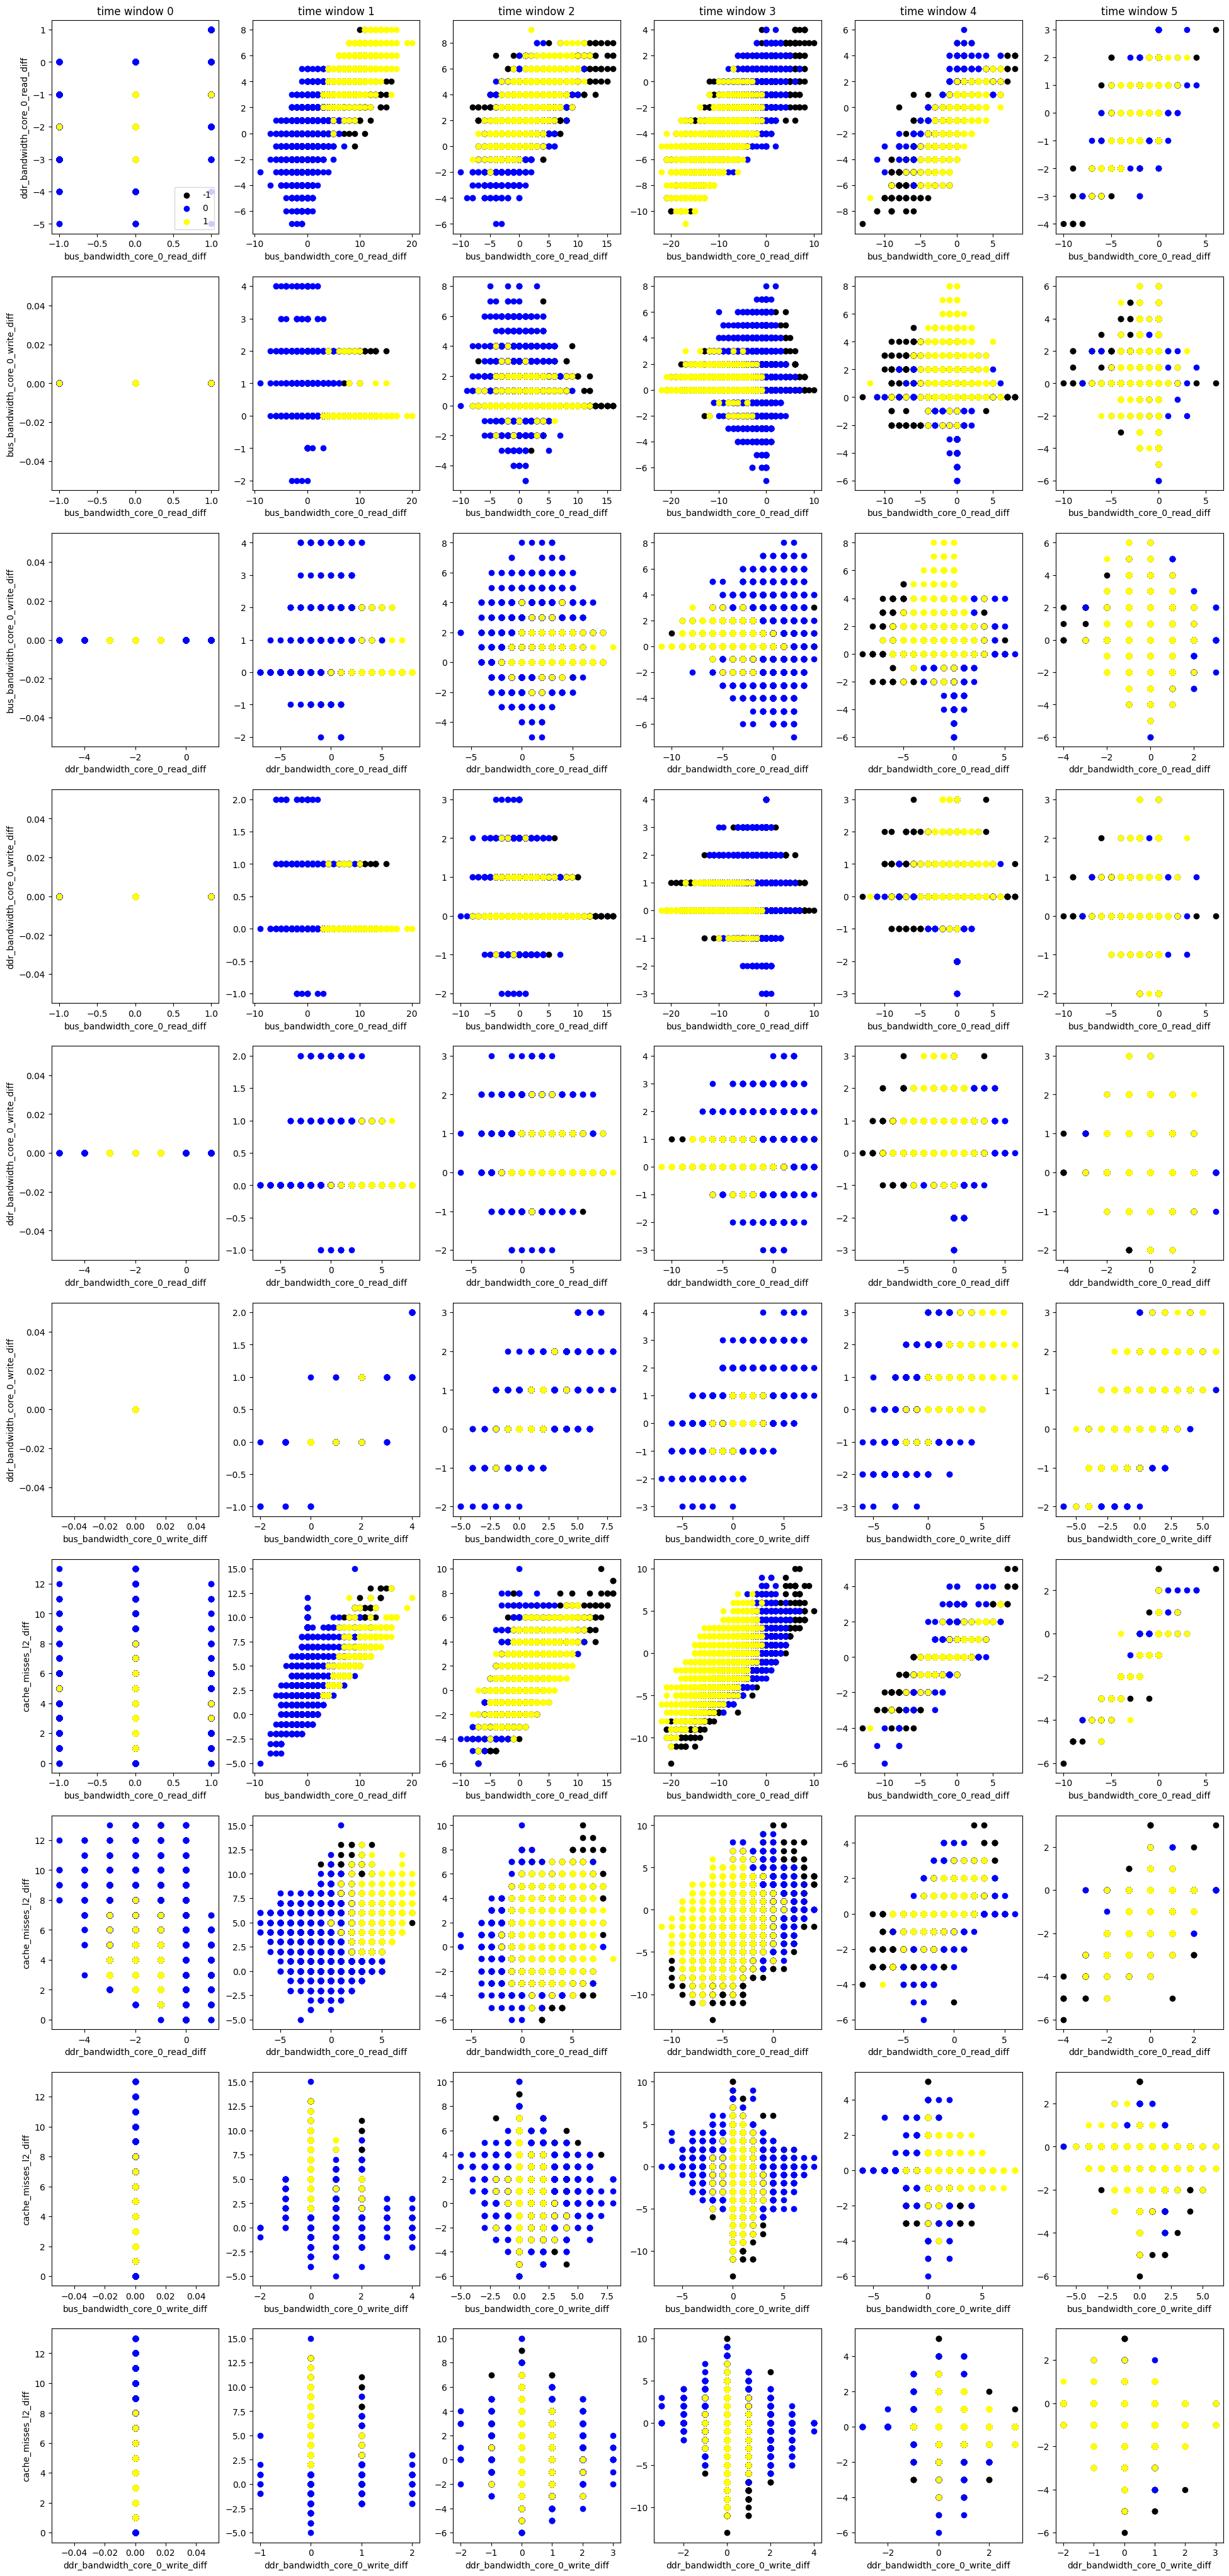

In [41]:
plot_clusters(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff'],clusters_imgep)
plot_clusters(['bus_bandwidth_core_0_read_diff', 'ddr_bandwidth_core_0_read_diff', 'bus_bandwidth_core_0_write_diff', 'ddr_bandwidth_core_0_write_diff', 'cache_misses_l2_diff'],clusters_imgep,figsize=(24,52))

In [49]:
def plot_trajectories_clusters(list_feature,figsize=(20,10)):
    fig,axes = plt.subplots(len(list_feature),2,figsize=figsize,sharex=True)
    for ligne,feature in enumerate(list_feature):
        for j in clusters_imgep:
            if j!=-1:
                a = np.array(clusters_imgep[j][feature])
                axes[ligne,0].plot(a.mean(axis=0),'-o',label=j)
                axes[ligne,1].plot(a.std(axis=0),'-o',label=j)
        axes[ligne,0].set_ylabel(feature)
    axes[0,0].legend()
    axes[0,0].set_title('mean value for each time window')
    axes[0,1].set_title('std value for each time window')
    axes[2,0].set_xlabel('time')
    axes[2,1].set_xlabel('time')
    plt.show()

# One can plot the mean values of the clusters along the time windows, however, std values are too high

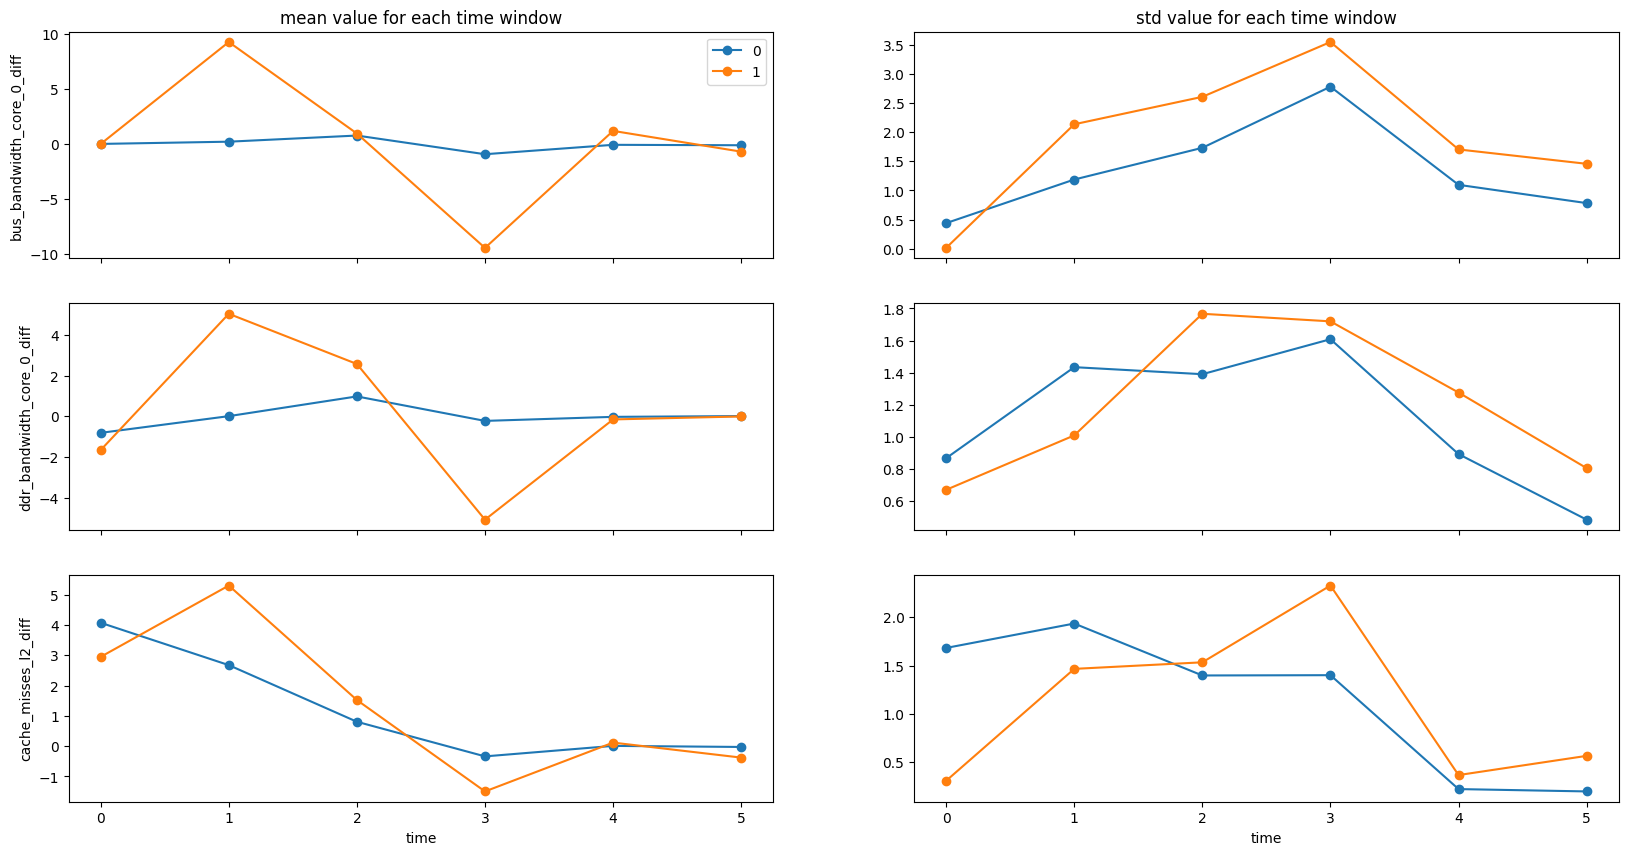

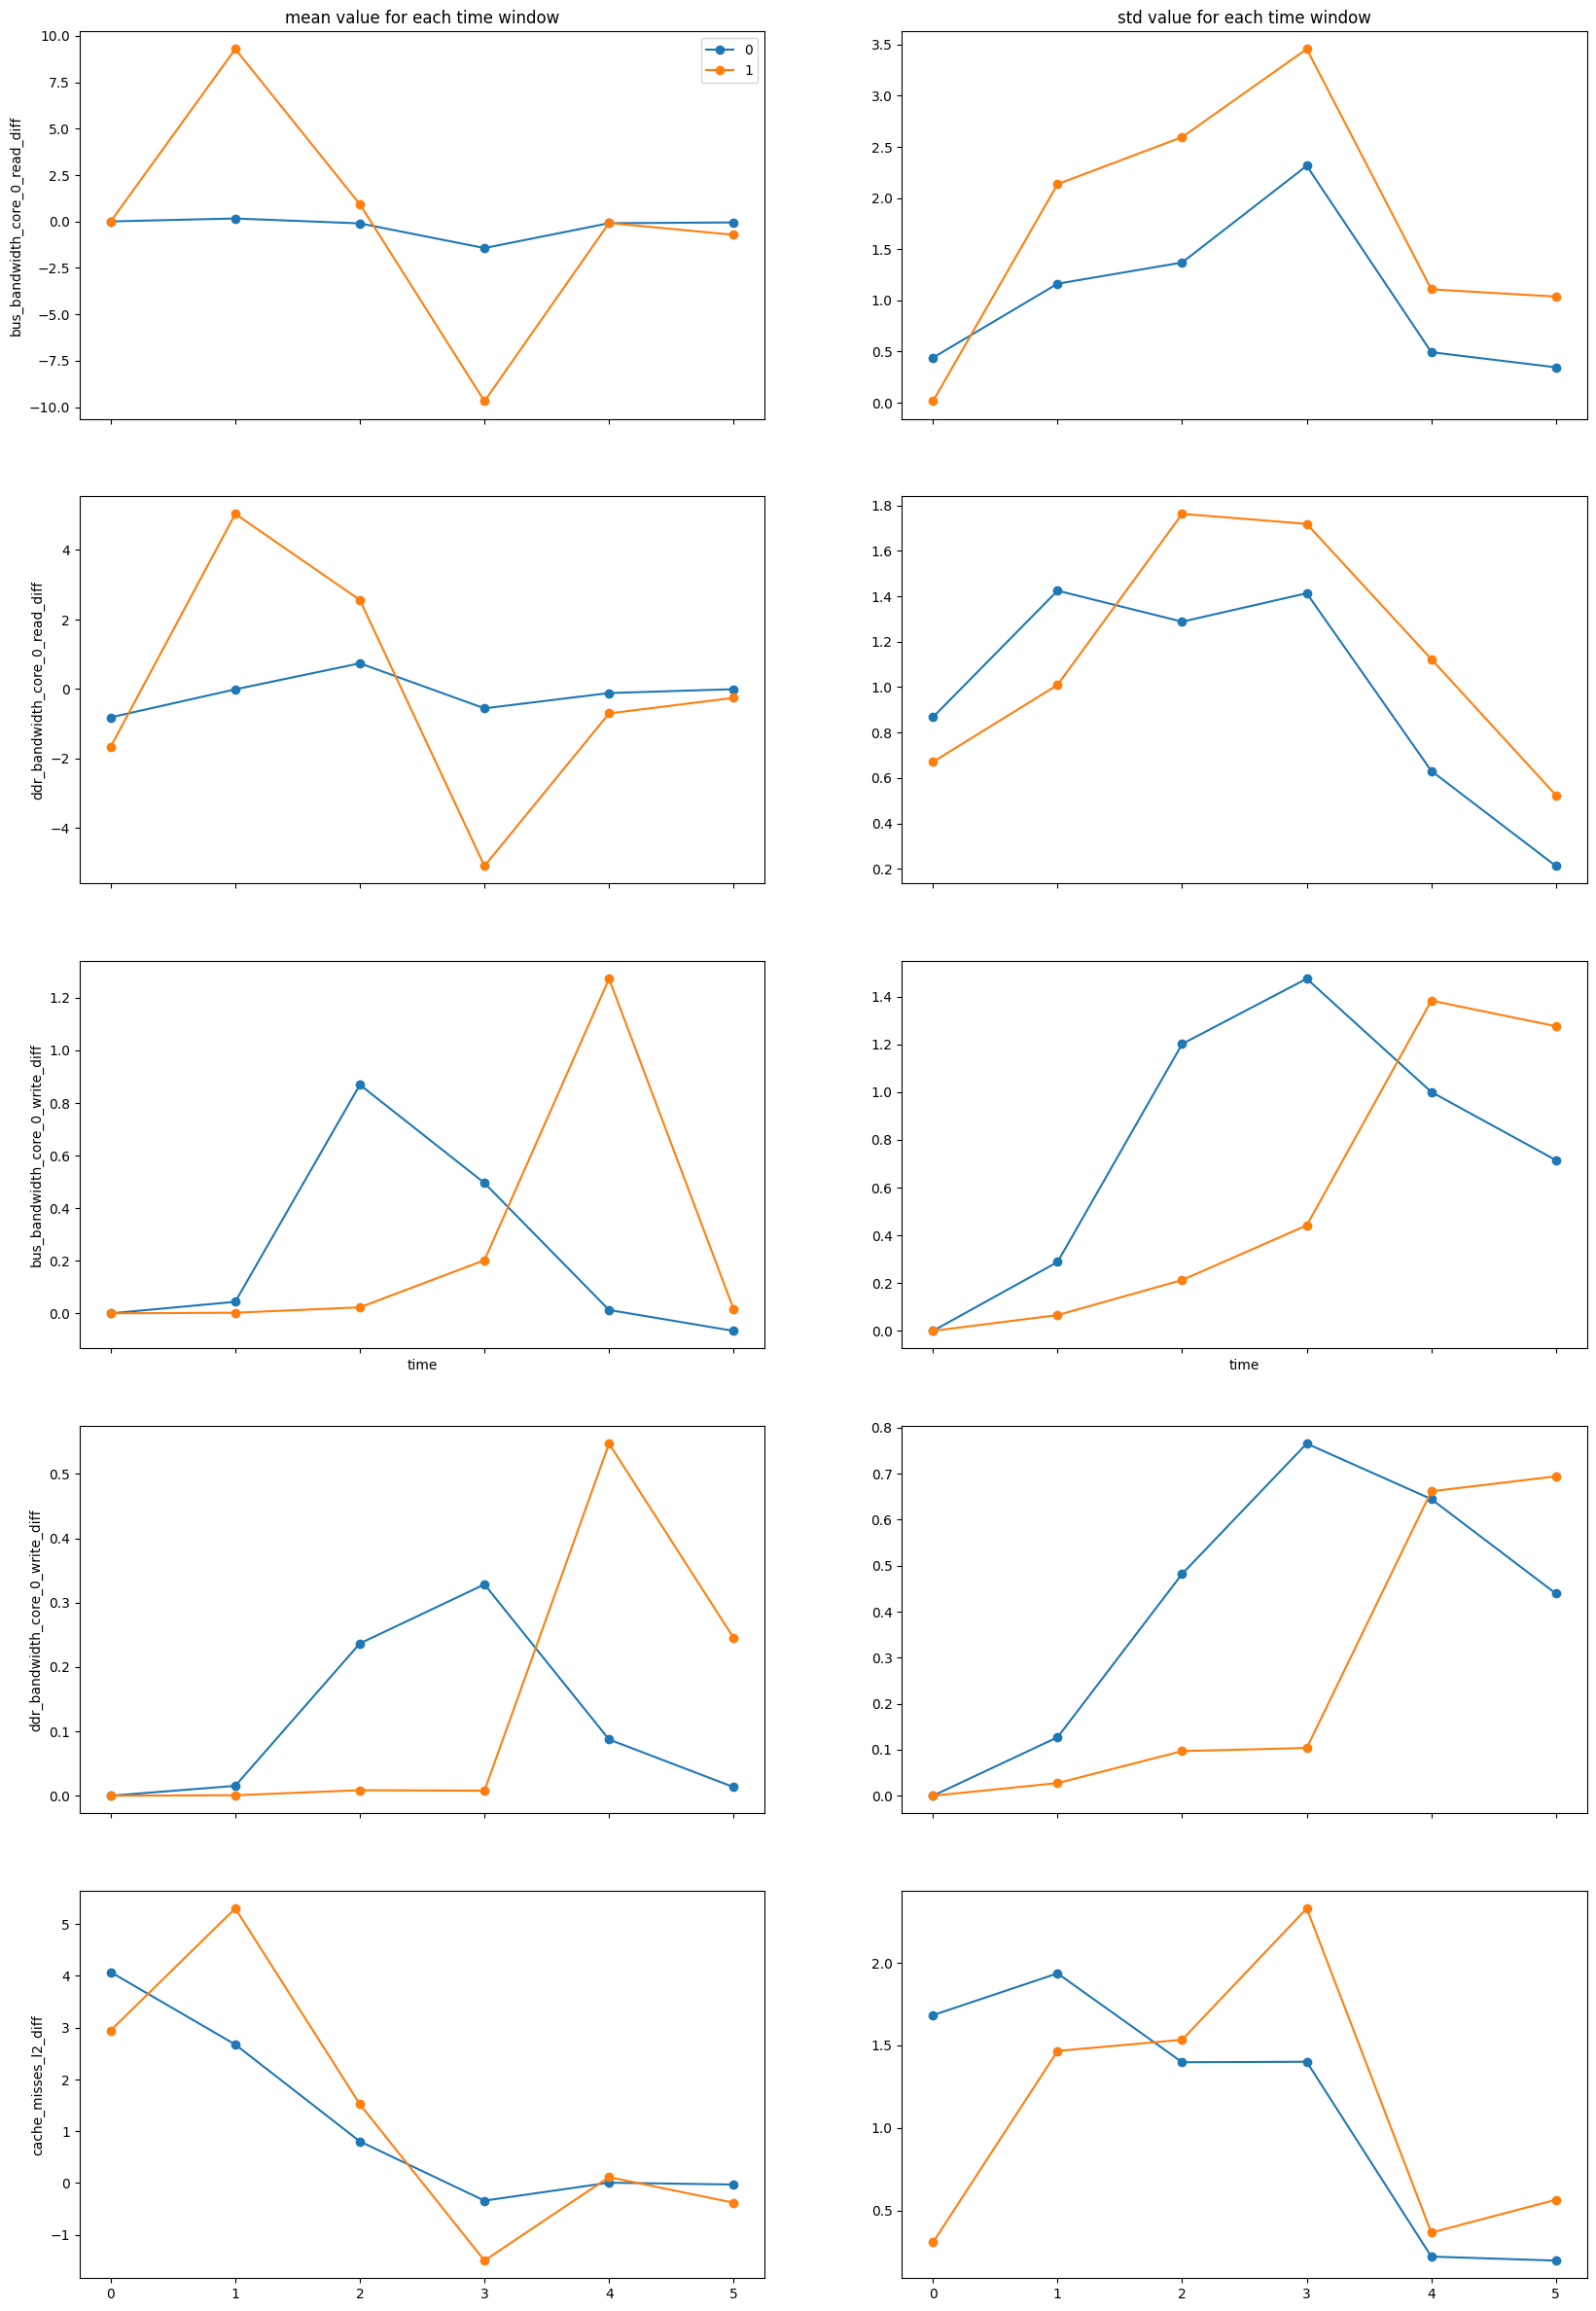

In [50]:
plot_trajectories_clusters(list_feature=['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff'])
plot_trajectories_clusters(list_feature=['bus_bandwidth_core_0_read_diff', 'ddr_bandwidth_core_0_read_diff', 'bus_bandwidth_core_0_write_diff', 'ddr_bandwidth_core_0_write_diff','cache_misses_l2_diff'],figsize=(20,30))

In [68]:
import pandas as pd

dic_cluster_2_corr = {}
feature_list = ['bus_bandwidth_core_0_read_diff', 'ddr_bandwidth_core_0_read_diff', 'cache_misses_l2_diff',
                'bus_bandwidth_core_0_write_diff', 'ddr_bandwidth_core_0_write_diff']
names_list = ['bus_bd_read_diff', 'ddr_bd_read_diff', 'cache_misses_l2_diff',
                'bus_bd_write_diff', 'ddr_bd_write_diff']
for cluster in clusters_imgep:
    list_df = []
    if cluster!=-1:
        for time in range(6):
            df = pd.DataFrame([])
            for feature in feature_list:
                if feature =='time_core0_diff':
                    pass
                     #df[feature] = np.array(clusters_imgep[cluster]['time_core0_core1']) - np.array(clusters_imgep[cluster]['time_core0_iso'])
                else:
                    df[feature] = np.array(clusters_imgep[cluster][feature])[:,time]
            list_df.append(df.corr())
        dic_cluster_2_corr[cluster] = list_df
#np.array(clusters_imgep[hdb.labels_[j]]['bus_bandwidth_core_0_diff']).shape

In [62]:
dic_cluster_2_corr[0][0].shape

(5, 5)

### Let's visualize the evolution of the covariance matrices with time. 

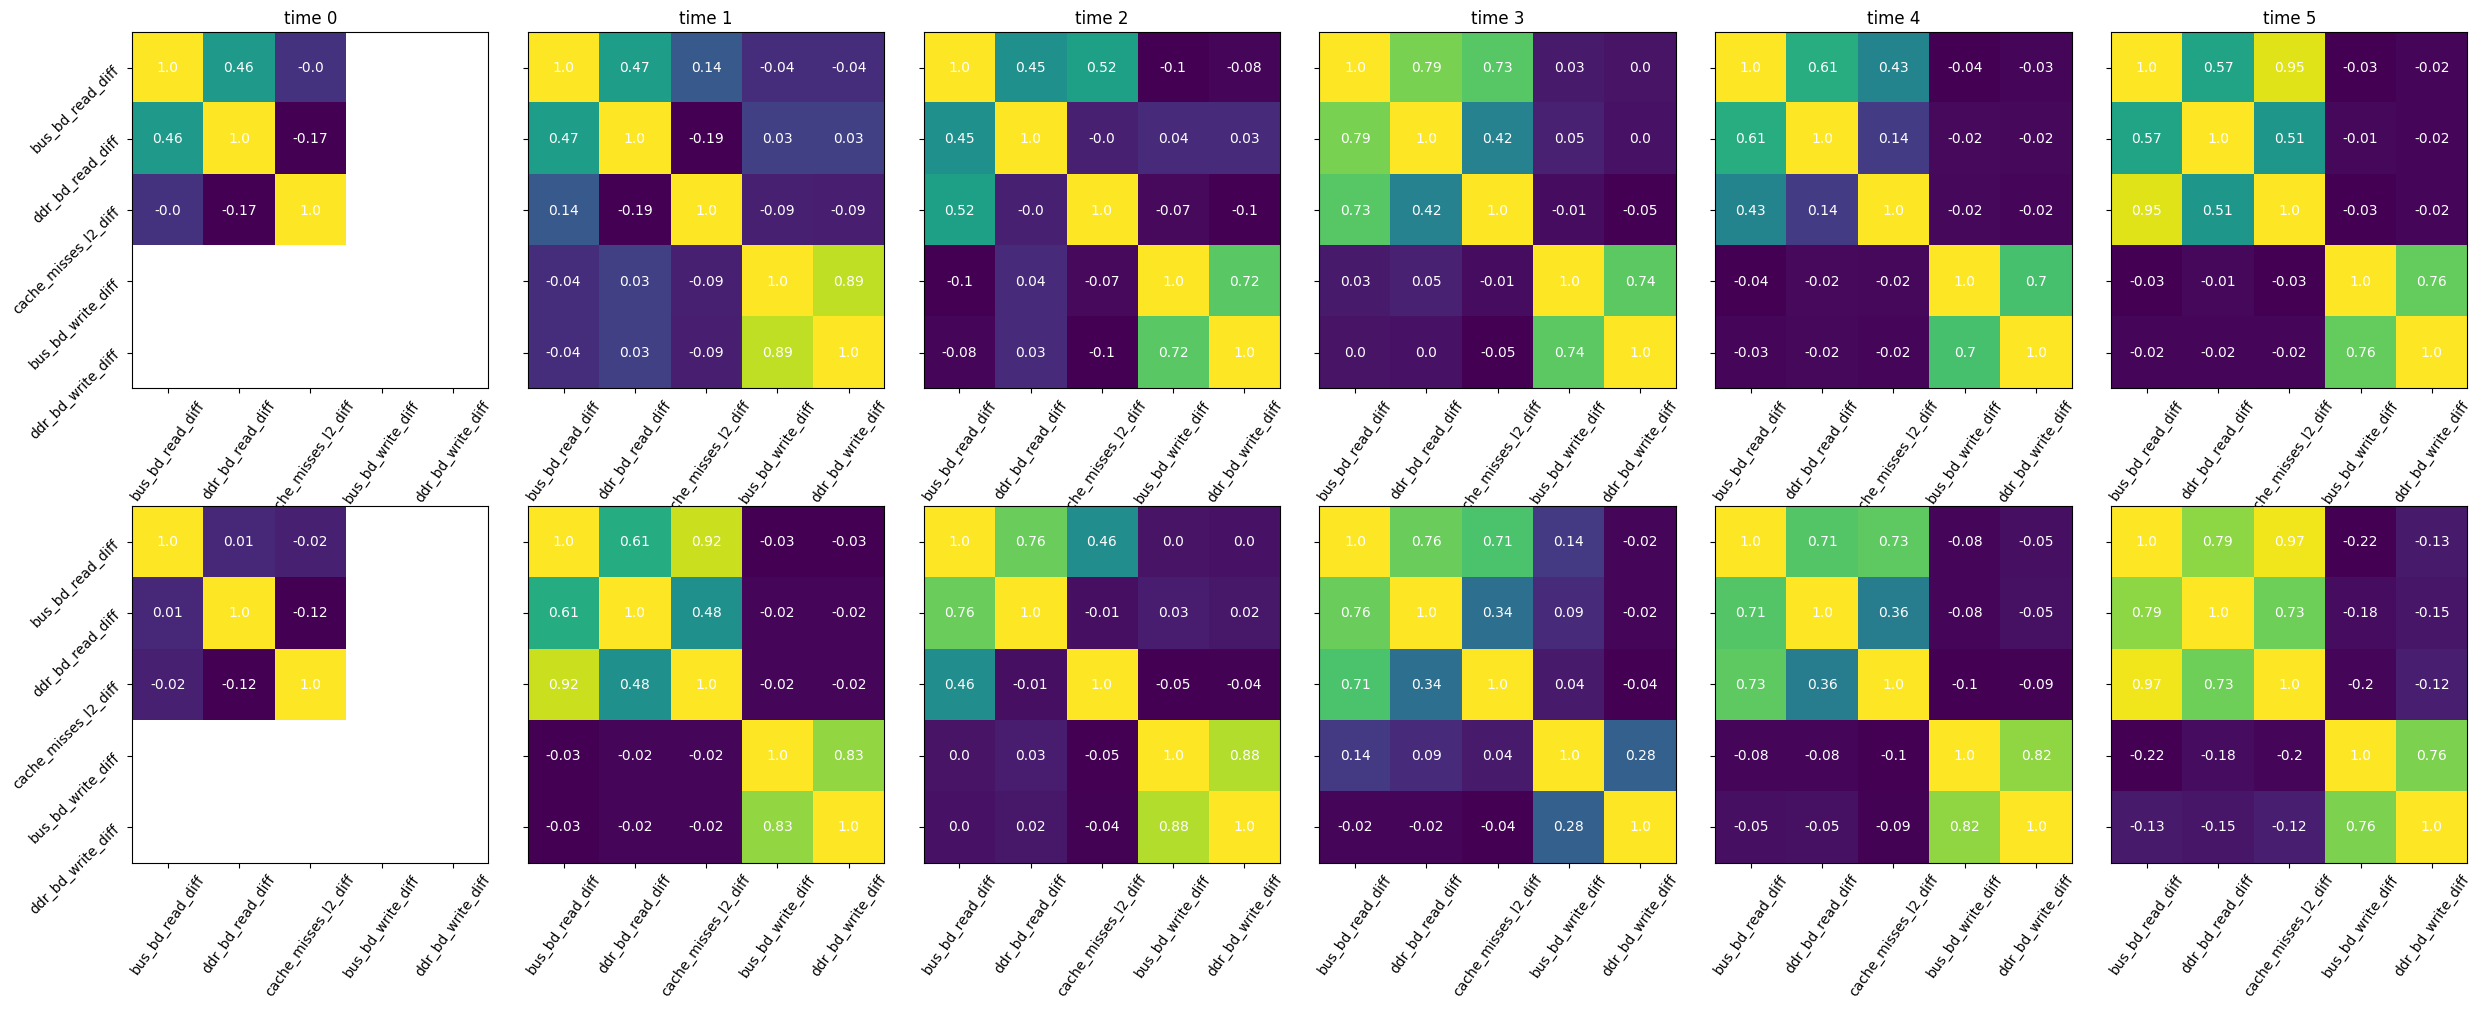

In [73]:
fig, axs = plt.subplots(len(clusters_imgep)-1,6, figsize=(25, 10),sharey=True)#,sharex=False)
for time in range(6):
    axs[0,time].set_title(f'time {time}')
    for clust in clusters_imgep:
        if clust!=-1:
            # Show all ticks and label them with the respective list entries
            axs[clust,time].imshow(dic_cluster_2_corr[clust][time])
            axs[clust,time].set_xticks(range(len(feature_list)), labels=names_list,rotation=55)
            axs[clust,time].set_yticks(range(len(feature_list)), labels=names_list,rotation=45)
            
            # Loop over data dimensions and create text annotations.
            for i in range(len(feature_list)):
                for j in range(len(feature_list)):
                    text = axs[clust,time].text(j, i, dic_cluster_2_corr[clust][time].values.round(2)[i, j],ha="center", va="center", color="w")
fig.tight_layout()
plt.show()

In [77]:
content_imgep['memory_observation'].keys()

dict_keys(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff', 'bus_bandwidth_core_0_iso', 'bus_bandwidth_core_0_core1', 'ddr_bandwidth_core_0_iso', 'ddr_bandwidth_core_0_core1', 'time_core0_iso', 'time_core0_core1'])

## HDBCAN directly on matrix data

In [ ]:
data.shape
hdb = HDBSCAN(copy=True, min_cluster_size=1000)
hdb.fit(data)

## Attempt to identify clusters with Kmeans on untouched simulator data
--> sklearn website to
"Silhouette analysis can be used to study the separation distance between the resulting clusters. The silhouette plot displays a measure of how close each point in one cluster is to points in the neighboring clusters and thus provides a way to assess parameters like number of clusters visually. This measure has a range of [-1, 1].

Silhouette coefficients (as these values are referred to as) near +1 indicate that the sample is far away from the neighboring clusters. A value of 0 indicates that the sample is on or very close to the decision boundary between two neighboring clusters and negative values indicate that those samples might have been assigned to the wrong cluster."

In [29]:
data = content_imgep['numpy_view']
max_min = data.max(axis=0) - data.min(axis=0)
norm_min_max = lambda data: (data - data.min(axis=0))/(1*max_min==0 + max_min)
data = norm_min_max(data)

In [30]:
inertias = []
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
for n_clusters in range(2,6):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(data)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(data, labels)
    print(
    "For n_clusters =",
    n_clusters,
    "The average silhouette_score is :",
    silhouette_avg,
    )
    inertias.append(kmeans.inertia_)

For n_clusters = 2 The average silhouette_score is : 0.4893720292100813
For n_clusters = 3 The average silhouette_score is : 0.28126057287198564
For n_clusters = 4 The average silhouette_score is : 0.13357199671029693
For n_clusters = 5 The average silhouette_score is : 0.13952018387831577


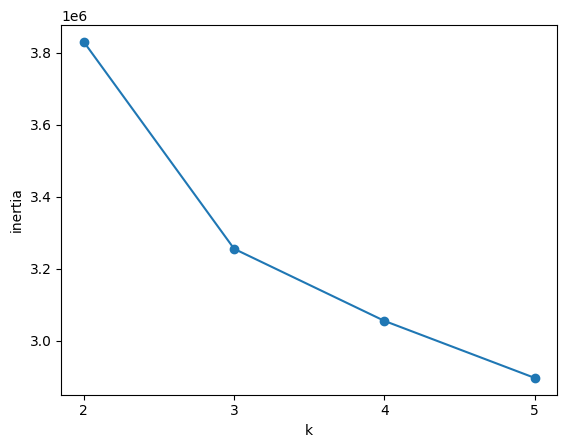

In [35]:
plt.figure()
plt.plot(range(2,6),inertias,'-o')
plt.ylabel('inertia')
plt.xlabel('k')
plt.xticks(range(2,6))
plt.show()

#### Elbow Method indicates that k=3 gives the best cluster when looking at the sum of squared distances of samples to their closest cluster center. However k=3 provides a poor silhouette score.